In [1]:
import datetime
import os
import pathlib
import sys

import dateutil.relativedelta
import IPython.display
import matplotlib
import matplotlib.dates
import matplotlib.patches
import matplotlib.pyplot
import numpy
import pandas
import swifter

INTRODUCTION_DIR = pathlib.Path.cwd() / "01_introduction"

os.environ["INTRODUCTION_DIR"] = str(INTRODUCTION_DIR)
if str(INTRODUCTION_DIR) not in sys.path:
    sys.path.append(str(INTRODUCTION_DIR))

from utils import list_code

# Introduction
## Download HTTP transfer size timeseries from HTTP archive and store as CSV

We provide `01_introduction/input_datasets/http_archive_bytes_total.csv` in our dataset. The code below documents how we gathered this data in case you want to generate your own, more updated time series.

In [2]:
df = pandas.read_json("https://cdn.httparchive.org/reports/bytesTotal.json")
df.to_csv(INTRODUCTION_DIR / "input_datasets" / "http_archive_bytes_total.csv")

## History of HTTP transfer sizes of web resources

The following code generates Figure 1 of our paper.

Pandas Apply:   0%|          | 0/503 [00:00<?, ?it/s]

### [HTTP Transfer Size](01_introduction/plots/http-archive-bytes-total.pdf)

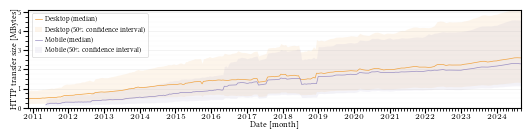

In [3]:
SLIDE_VERSION = False                   # Set to True for styling for slide set
END_DATE = datetime.date(2024, 9, 1)    # Fixed for reproducability, increase this value for newer timeseries

if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullslide.mplstyle")
    matplotlib.use("pgf")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1] * 1.5
else:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth.mplstyle")
    matplotlib.use("inline")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.16, matplotlib.rcParams["figure.figsize"][1] * 3 / 4

matplotlib.pyplot.rc('axes', prop_cycle=matplotlib.pyplot.cycler(color=["#f1a340", "#998ec3"]))
df = pandas.read_csv(INTRODUCTION_DIR / "input_datasets" / "http_archive_bytes_total.csv")
df["client"] = df["client"].swifter.apply(lambda x: x.title())

p25 = df.groupby(["client", "timestamp"])[["p25"]].sum().unstack().T.reset_index().drop(columns=["level_0"])
p25 = p25.sort_values(["timestamp"])
p25["timestamp"] = p25["timestamp"].swifter.apply(pandas.to_datetime).dt.date
p25 = p25.set_index(["timestamp"]).interpolate(method="linear")

p75 = df.groupby(["client", "timestamp"])[["p75"]].sum().unstack().T.reset_index().drop(columns=["level_0"])
p75 = p75.sort_values(["timestamp"])
p75["timestamp"] = p75["timestamp"].swifter.apply(pandas.to_datetime).dt.date
p75 = p75.set_index(["timestamp"]).interpolate(method="linear")

p50 = df.groupby(["client", "timestamp"])[["p50"]].sum().unstack().T.reset_index().drop(columns=["level_0"])
p50 = p50.sort_values(["timestamp"])
p50["timestamp"] = p50["timestamp"].swifter.apply(pandas.to_datetime).dt.date
p50 = p50.set_index(["timestamp"]).interpolate(method="linear")
ax = p50.plot(legend=False, color={"Desktop": "C0", "Mobile": "C1"})
matplotlib.pyplot.fill_between(p25.index, p25["Desktop"], p75["Desktop"], color='C0', alpha=0.1, linewidth=0)
matplotlib.pyplot.fill_between(p25.index, p25["Mobile"], p75["Mobile"], color='C1', alpha=0.1, linewidth=0)
ax.set_xlabel("Date [month]")
ax.set_xlim((p50.index.min(), END_DATE))
ax.set_xticks(pandas.date_range(p50.index.min() + dateutil.relativedelta.relativedelta(month=1), END_DATE, freq="1YS"))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator())
    
ax.set_ylabel("HTTP transfer size [MBytes]")
ax.set_ylim((0, 5 * 1024 + 128))
ax.set_yticks(numpy.arange(0, 5 * 1024 + 1, 1024))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(n=4))
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="minor", linewidth=0.1)
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="major", linewidth=0.5)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"{y // 1024}"))

handles, labels = ax.get_legend_handles_labels()
labels = [f"{label} (median)" for label in labels]
handles = [
    handles[0],
    matplotlib.patches.Patch(facecolor="C0", alpha=0.1, linewidth=0),
    handles[1],
    matplotlib.patches.Patch(facecolor="C1", alpha=0.1, linewidth=0),
]
labels = [
    labels[0],
    r"Desktop (50\% confidence interval)",
    labels[1],
    r"Mobile (50\% confidence interval)",
]
ax.legend(handles=handles, labels=labels, loc="upper left")
# add p25-p75 

if not (INTRODUCTION_DIR / "plots").exists():
    (INTRODUCTION_DIR / "plots").mkdir()

filepath = INTRODUCTION_DIR / "plots" / "http-archive-bytes-total.pdf"
IPython.display.display(IPython.display.Markdown(f"### [HTTP Transfer Size]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)

## History of JSON request ratio on desktop

We fetched this data using the HTTP Archive BigQuery database.
From the [HTTP Archive FAQ](https://web.archive.org/web/20240921023218/https://httparchive.org/faq#how-do-i-use-bigquery-to-write-custom-queries-over-the-data) in September, 2024:

> How do I use BigQuery to write custom queries over the data?
> 
> The HTTP Archive dataset is available on BigQuery. Be aware that as a consequence of collecting so much metadata from millions of websites each month, the dataset is extremely large—multiple petabytes. Care must be taken to set up [cost controls](https://cloud.google.com/bigquery/docs/custom-quotas) to avoid unexpected bills. Also see our guide to [minimizing query costs](https://har.fyi/guides/minimizing-costs/) for tips on staying under the 1 TB per month free quota.
> 
> Check out [Getting Started Accessing the HTTP Archive with BigQuery](https://github.com/HTTPArchive/httparchive.org/blob/main/docs/gettingstarted_bigquery.md) [now moved to, a guide for first-time users written by [Paul Calvano](https://twitter.com/paulcalvano).
> 
> For a guided walkthrough of the project, watch this in-depth [30 minute video](https://www.youtube.com/watch?v=00f9kza3BJ0) featuring HTTP Archive maintainer [Rick Viscomi](https://twitter.com/rick_viscomi).
> 
> If you have any questions about using BigQuery, reach out to the HTTP Archive community at [discuss.httparchive.org](https://discuss.httparchive.org/).

Below you can find our SQL query we used against BigQuery. **Careful, this will consume 758,14 GB of your monthly allocated 1 TB quota!**

In [4]:
list_code(INTRODUCTION_DIR / "input_datasets" / "bq-results-20240926-131645-1727356734135.sql")

/* Based on https://discuss.httparchive.org/t/median-of-application-json-or-xml-requests-within-a-page/1643/2 */
SELECT 
t1.table_name as table_suffix,
total_requests,
total_json_requests,
total_json_requests/total_requests as percent_json_requests,
FROM (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_json_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  LOWER(mimeType) LIKE "%json%" AND _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t1 
JOIN (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t2 ON t1.table_name = t2.table_name
ORDER BY table_suffix

### [JSON Request Ratio](01_introduction/plots/http-archive-json-request-ratio.pdf)

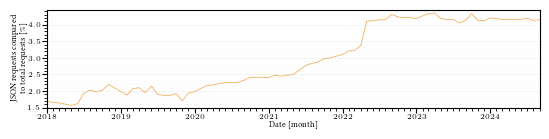

In [5]:
SLIDE_VERSION = False                   # Set to True for styling for slide set

if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullslide.mplstyle")
    matplotlib.use("pgf")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1] * 1.5
else:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth.mplstyle")
    matplotlib.use("inline")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.16, matplotlib.rcParams["figure.figsize"][1] * 3 / 4
    
df = pandas.read_csv(
    INTRODUCTION_DIR / "input_datasets" / "bq-results-20240926-131645-1727356734135.csv"
)
df["timestamp"] = df["table_suffix"].swifter.apply(lambda x: pandas.to_datetime(x, format="%y_%m_%d_desktop")).dt.date
df = df.set_index(["timestamp"]).interpolate(method="linear")

ax = df["percent_json_requests"].plot(legend=False, color={"percent_json_requests": "C0"})
ax.set_xlabel("Date [month]")
ax.set_xlim((df.index.min(), df.index.max()))
ax.set_xticks(pandas.date_range(df.index.min() + dateutil.relativedelta.relativedelta(month=1), df.index.max(), freq="1YS"))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator())

ax.set_ylabel("JSON requests compared\nto total requests [\\%]")
ax.set_ylim((0.015, 0.0445))
ax.set_yticks(numpy.arange(0.015, 0.045, 0.005))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y * 100:0.1f}$"))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.001))
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="minor", linewidth=0.1)
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="major", linewidth=0.5)
filepath = INTRODUCTION_DIR / "plots" / "http-archive-json-request-ratio.pdf"
IPython.display.display(IPython.display.Markdown(f"### [JSON Request Ratio]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)